# Analysis of Data Sources from PV

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import distance_matrix
import numpy as np
from scipy.stats import skew
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.dates as mdates
import os, sys

from pathlib import Path
from datetime import datetime, timedelta # Import datetime and timedelta

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))

from scripts.model.OBKNN.model_OnlineBootKNN import transform_instance
from capymoa.instance import Instance
from capymoa.stream import Schema


In [56]:
# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent


FONTSIZE_MAIN = 11
FONTSIZE_SEC = 10

In [57]:

NAME_FILE = "137_CreditCard_id_1_Finance_tr_500_1st_541"+".csv"
result = pd.read_csv(current_dir / "datasets" / "raw" / "TSB-AD-M-lite" / NAME_FILE, sep=',', encoding='ISO-8859-1')
#result = pd.read_csv(current_dir / "datasets" / "raw" / "TSB-AD-U-lite" / NAME_FILE, sep=',', encoding='ISO-8859-1')

In [58]:
result.columns[:]

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Label'],
      dtype='object')

In [59]:
result.columns[-1]

'Label'

In [60]:
result.insert(0, 'CURRENTTIMESTAMP', pd.to_datetime(range(len(result))))
result.CURRENTTIMESTAMP


0        1970-01-01 00:00:00.000000000
1        1970-01-01 00:00:00.000000001
2        1970-01-01 00:00:00.000000002
3        1970-01-01 00:00:00.000000003
4        1970-01-01 00:00:00.000000004
                      ...             
284802   1970-01-01 00:00:00.000284802
284803   1970-01-01 00:00:00.000284803
284804   1970-01-01 00:00:00.000284804
284805   1970-01-01 00:00:00.000284805
284806   1970-01-01 00:00:00.000284806
Name: CURRENTTIMESTAMP, Length: 284807, dtype: datetime64[ns]

In [61]:
min_date = result.CURRENTTIMESTAMP.min()
print("Min Date:", min_date)


Min Date: 1970-01-01 00:00:00


In [62]:
max_date = result.CURRENTTIMESTAMP.max()
print("Max Date:", max_date)

Max Date: 1970-01-01 00:00:00.000284806


In [63]:

min_date_filter = result['CURRENTTIMESTAMP']>="1800-08-08 16:55"
Components_final = result[min_date_filter]
print("Min Date:", min_date)

Min Date: 1970-01-01 00:00:00


In [64]:
max_date_filter = Components_final['CURRENTTIMESTAMP']<="2027-08-08 17:03"
Components_final = Components_final[max_date_filter]
print("Max Date:", max_date)

Max Date: 1970-01-01 00:00:00.000284806


In [65]:
print("Length:",len(Components_final))

Length: 284807


## Analysing Datasets

In [66]:

result = Components_final

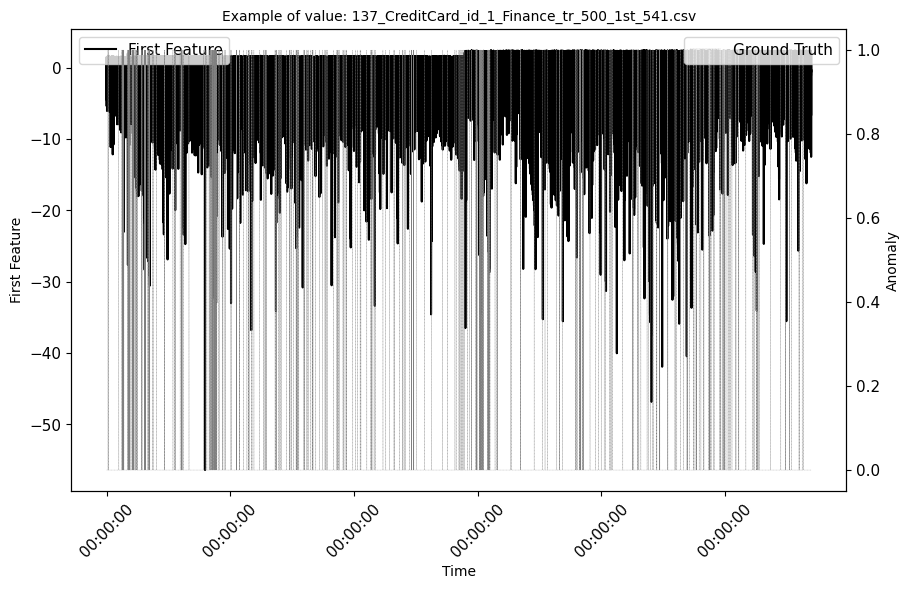

In [67]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:,1], color="black", label="First Feature")
#ax1.plot(result.CURRENTTIMESTAMP, result["CURRENT"], color="red", label="Current")
#ax1.plot(result.CURRENTTIMESTAMP, result["VOLTAGE"], color="blue", label="Voltage")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('First Feature', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of value: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["Label"], color="grey", linestyle="dashed", label="Ground Truth", linewidth=0.2)
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No Ground Truth available")

plt.show()

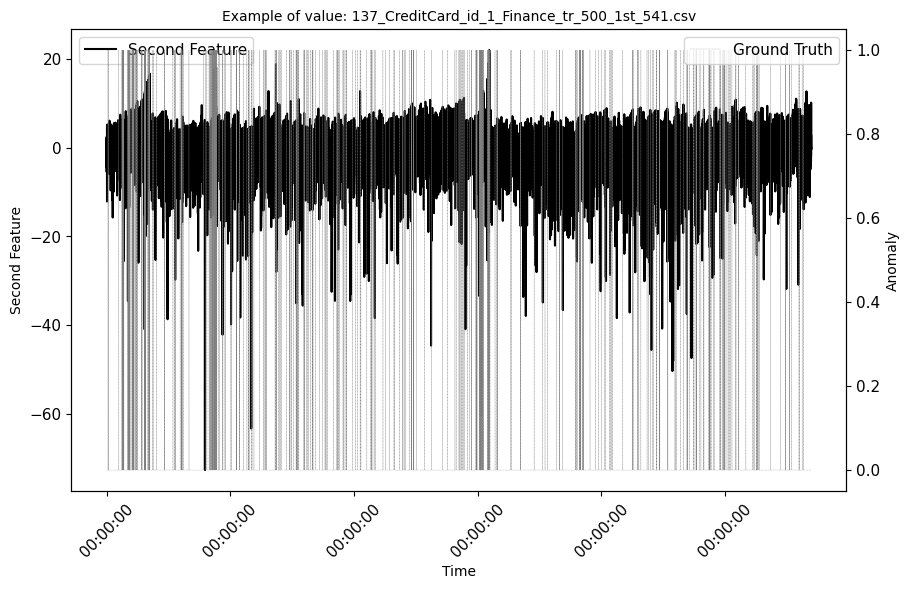

In [68]:
fig, ax1 = plt.subplots(figsize=(10, 6))

#ax1.plot(result.CURRENTTIMESTAMP, result["PRESSURE"], color="green", label="Pressure")
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:,2], color="black", label="Second Feature")
#ax1.plot(result.CURRENTTIMESTAMP, result["VOLTAGE"], color="blue", label="Voltage")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Second Feature', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of value: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["Label"], color="grey", linestyle="dashed", label="Ground Truth", linewidth=0.2)
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No Ground Truth available")

plt.show()

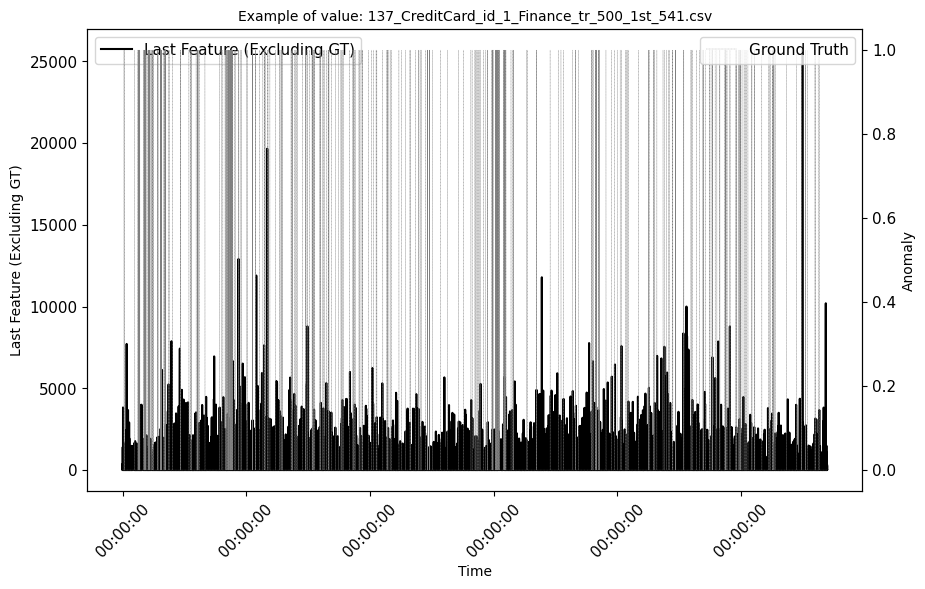

In [69]:
fig, ax1 = plt.subplots(figsize=(10, 6))

#ax1.plot(result.CURRENTTIMESTAMP, result["PRESSURE"], color="green", label="Pressure")
#ax1.plot(result.CURRENTTIMESTAMP, result["CURRENT"], color="red", label="Current")
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:,-2], color="black", label="Last Feature (Excluding GT)")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Last Feature (Excluding GT)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of value: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["Label"], color="grey", linestyle="dashed", label="Ground Truth", linewidth=0.2)
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No Ground Truth available")

plt.show()

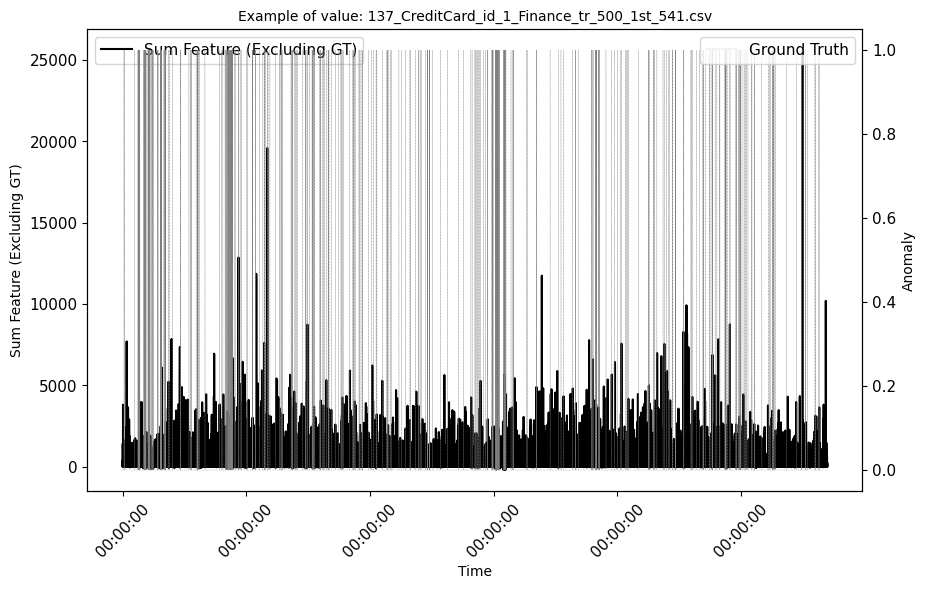

In [70]:
fig, ax1 = plt.subplots(figsize=(10, 6))

#ax1.plot(result.CURRENTTIMESTAMP, result["PRESSURE"], color="green", label="Pressure")
#ax1.plot(result.CURRENTTIMESTAMP, result["CURRENT"], color="red", label="Current")
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:,1:-1].sum(axis=1), color="black", label="Sum Feature (Excluding GT)")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Sum Feature (Excluding GT)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of value: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["Label"], color="grey", linestyle="dashed", label="Ground Truth", linewidth=0.2)
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No Ground Truth available")

plt.show()